## Overview

This project analyzes product feature adoption, customer behavior, and revenue patterns to support data-driven Go-to-Market (GTM) decisions.

Key questions include:
- Which features drive the most engagement?
- How does adoption vary across regions?
- Which customer segments generate the most value?

## Business Problem

The company offers multiple product features, but lacks visibility into:

- Which features truly drive engagement
- How usage differs across regions
- Which customer segments are most valuable

Without this insight, sales and product teams cannot effectively prioritize growth efforts.

This analysis aims to bridge that gap using data.

## Data Description

The dataset consists of four tables:

- customers: customer attributes (region, company size, industry)
- features: product feature definitions
- usage_events: feature usage behavior
- revenue: revenue generated by customers

These tables are joined through customer_id and feature_id.

## Data Loading

In [4]:
import pandas as pd

customers = pd.read_csv("customers.csv")
features = pd.read_csv("features.csv")
usage_events = pd.read_csv("usage_events.csv")
revenue = pd.read_csv("revenue.csv")


customers.info()
features.info()
usage_events.info()
revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   200 non-null    int64 
 1   region        200 non-null    object
 2   company_size  200 non-null    object
 3   industry      200 non-null    object
dtypes: int64(1), object(3)
memory usage: 6.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   feature_id    4 non-null      int64 
 1   feature_name  4 non-null      object
dtypes: int64(1), object(1)
memory usage: 196.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  1500 non-null   int64 
 1   feature_id   1500 non-null   int64 
 

## KPI Definition

We define key business metrics:

- Feature Adoption Rate  
  → % of customers using a feature  

- Usage Intensity  
  → Total usage volume per customer  

- Revenue per Customer  
  → Total revenue contribution  

- Segment Performance  
  → Combined view of usage and revenue by segment

## Analysis 1: Feature Adoption

We first examine overall feature adoption across all customers.

In [6]:
# 总客户数
total_customers = customers["customer_id"].nunique()

# 每个feature有多少客户用过
feature_users = usage_events.groupby("feature_id")["customer_id"].nunique().reset_index()

# 计算adoption rate
feature_users["adoption_rate"] = feature_users["customer_id"] / total_customers

# 加上feature name
feature_users = feature_users.merge(features, on="feature_id")

feature_users

,feature_id,customer_id,adoption_rate,feature_name
0,1,170,0.850,Analytics
1,2,172,0.860,Automation
2,3,173,0.865,Reporting
3,4,172,0.860,AI Insights


### Insight

All features show consistently high adoption rates (~85%+), indicating strong overall product engagement. However, the lack of variation suggests the need to further analyze usage intensity and revenue contribution to differentiate feature performance.

## Analysis 2: Feature Adoption by Region

We analyze how feature adoption varies across regions.

In [8]:
# 1. usage + customer info
region_feature = usage_events.merge(customers, on="customer_id")

# 2. 每个 region 下，每个 feature 的使用客户数
region_feature_users = (
    region_feature.groupby(["region", "feature_id"])["customer_id"]
    .nunique()
    .reset_index(name="users")
)

# 3. 每个 region 的总客户数
region_totals = (
    customers.groupby("region")["customer_id"]
    .nunique()
    .reset_index(name="total_customers")
)

# 4. 合并并计算 adoption rate
region_feature_adoption = region_feature_users.merge(region_totals, on="region")
region_feature_adoption["adoption_rate"] = (
    region_feature_adoption["users"] / region_feature_adoption["total_customers"]
)

# 5. 加上 feature name
region_feature_adoption = region_feature_adoption.merge(features, on="feature_id")

region_feature_adoption.sort_values(["feature_name", "region"])

,region,feature_id,users,total_customers,adoption_rate,feature_name
3,Asia,4,67,73,0.917808,AI Insights
7,Europe,4,46,61,0.754098,AI Insights
11,North America,4,59,66,0.893939,AI Insights
0,Asia,1,59,73,0.808219,Analytics
4,Europe,1,51,61,0.836066,Analytics
8,North America,1,60,66,0.909091,Analytics
1,Asia,2,63,73,0.863014,Automation
5,Europe,2,52,61,0.852459,Automation
9,North America,2,57,66,0.863636,Automation
2,Asia,3,62,73,0.849315,Reporting


## Step 5: Identify High-Value Customer Segments

### Objective
Identify customer segments that generate both high product usage and high revenue.  
These segments represent high-value opportunities for sales and Go-to-Market (GTM) prioritization.

---

###  Calculate Total Usage per Customer

Aggregate total feature usage for each customer.

In [9]:
customer_usage = (
    usage_events.groupby("customer_id")["usage_count"]
    .sum()
    .reset_index(name="total_usage")
)

###  Calculate Total Revenue per Customer

Aggregate total revenue generated by each customer.

In [10]:
customer_revenue = (
    revenue.groupby("customer_id")["revenue"]
    .sum()
    .reset_index(name="total_revenue")
)

### Combine Usage, Revenue, and Customer Attributes

Merge usage and revenue metrics with customer demographic information.

In [11]:
customer_metrics = customer_usage.merge(customer_revenue, on="customer_id")
customer_metrics = customer_metrics.merge(customers, on="customer_id")

customer_metrics.head()

,customer_id,total_usage,total_revenue,region,company_size,industry
0,1,65,5639,Asia,Small,Manufacturing
1,2,21,6619,North America,Medium,Retail
2,3,48,4823,Asia,Small,Retail
3,4,42,7943,Asia,Medium,Manufacturing
4,5,54,674,North America,Medium,Finance


### Analyze Performance by Segment

Group customers by region and company size to evaluate average usage and revenue.

In [15]:
# 计算整体均值
usage_mean = segment_analysis["total_usage"].mean()
revenue_mean = segment_analysis["total_revenue"].mean()

# 分类
def classify(row):
    if row["total_usage"] >= usage_mean and row["total_revenue"] >= revenue_mean:
        return "High Usage - High Revenue"
    elif row["total_usage"] >= usage_mean and row["total_revenue"] < revenue_mean:
        return "High Usage - Low Revenue"
    elif row["total_usage"] < usage_mean and row["total_revenue"] >= revenue_mean:
        return "Low Usage - High Revenue"
    else:
        return "Low Usage - Low Revenue"

segment_analysis["segment_type"] = segment_analysis.apply(classify, axis=1)

segment_analysis

,region,company_size,total_usage,total_revenue,segment_type
0,Asia,Large,39.545455,6807.954545,High Usage - Low Revenue
1,Asia,Medium,37.812500,6241.125000,High Usage - Low Revenue
2,Asia,Small,42.062500,9728.656250,High Usage - High Revenue
3,Europe,Large,38.454545,8074.272727,High Usage - High Revenue
4,Europe,Medium,32.571429,8934.809524,Low Usage - High Revenue
5,Europe,Small,36.230769,8233.076923,Low Usage - High Revenue
6,North America,Large,36.444444,6800.833333,Low Usage - Low Revenue
7,North America,Medium,36.076923,8663.692308,Low Usage - High Revenue
8,North America,Small,40.500000,6931.600000,High Usage - Low Revenue


###  Visualize Segment Performance

Plot each segment based on average usage (x-axis) and average revenue (y-axis).  
This helps identify high-value segments with strong engagement and monetization.

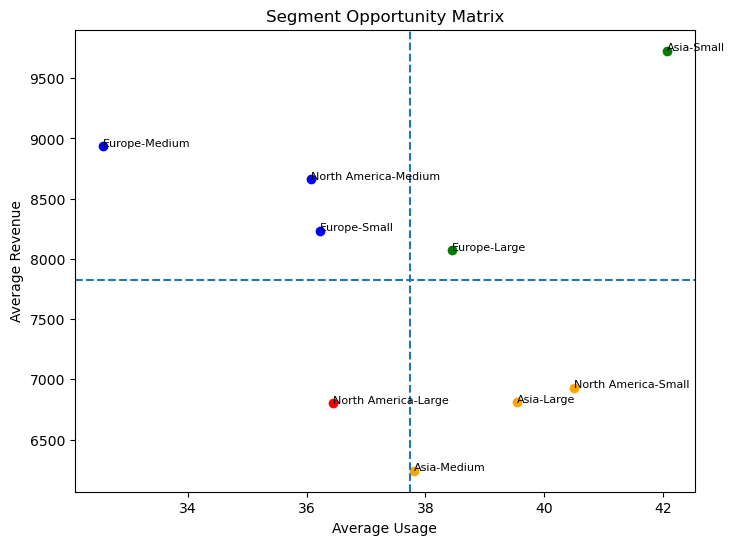

In [16]:
import matplotlib.pyplot as plt

colors = {
    "High Usage - High Revenue": "green",
    "High Usage - Low Revenue": "orange",
    "Low Usage - High Revenue": "blue",
    "Low Usage - Low Revenue": "red"
}

plt.figure(figsize=(8,6))

for _, row in segment_analysis.iterrows():
    plt.scatter(row["total_usage"], row["total_revenue"],
                color=colors[row["segment_type"]])
    
    plt.text(row["total_usage"], row["total_revenue"],
             f"{row['region']}-{row['company_size']}",
             fontsize=8)

plt.axvline(usage_mean, linestyle="--")
plt.axhline(revenue_mean, linestyle="--")

plt.xlabel("Average Usage")
plt.ylabel("Average Revenue")
plt.title("Segment Opportunity Matrix")

plt.show()

### Insight

Adoption rates vary across regions, with certain features showing stronger performance in specific markets. This suggests regional differences in product usage patterns and potential opportunities for localized GTM strategies.

## Analysis 3: Segment Performance (Usage vs Revenue)

We evaluate customer segments based on usage intensity and revenue contribution.

In [17]:
df = usage_events.merge(customers, on="customer_id")
df = df.merge(features, on="feature_id")

df.head()

,customer_id,feature_id,date,usage_count,region,company_size,industry,feature_name
0,75,1,2025-01-11,6,Europe,Small,Retail,Analytics
1,157,2,2025-01-12,8,Asia,Small,Retail,Automation
2,120,1,2025-03-15,4,Europe,Medium,Manufacturing,Analytics
3,164,3,2025-01-08,2,Europe,Medium,Finance,Reporting
4,21,2,2025-01-24,5,North America,Small,Retail,Automation


###  Aggregate Feature Usage by Segment

In [18]:
feature_segment_usage = (
    df.groupby(["region", "company_size", "feature_name"])["usage_count"]
    .sum()
    .reset_index()
)

feature_segment_usage

,region,company_size,feature_name,usage_count
0,Asia,Large,AI Insights,255
1,Asia,Large,Analytics,222
2,Asia,Large,Automation,229
3,Asia,Large,Reporting,189
4,Asia,Medium,AI Insights,165
5,Asia,Medium,Analytics,128
6,Asia,Medium,Automation,175
7,Asia,Medium,Reporting,161
8,Asia,Small,AI Insights,345
9,Asia,Small,Analytics,376


### Create Pivot Table

In [19]:
pivot_feature_segment = feature_segment_usage.pivot_table(
    index=["region", "company_size"],
    columns="feature_name",
    values="usage_count"
)

pivot_feature_segment

feature_name                AI Insights  Analytics  Automation  Reporting
region        company_size                                               
Asia          Large               255.0      222.0       229.0      189.0
              Medium              165.0      128.0       175.0      161.0
              Small               345.0      376.0       351.0      308.0
Europe        Large               203.0      255.0       325.0      180.0
              Medium              186.0      174.0       197.0      162.0
              Small                73.0      118.0       149.0      159.0
North America Large               183.0      195.0       133.0      145.0
              Medium              287.0      259.0       227.0      165.0
              Small               197.0      239.0       271.0      213.0

###  Visualize Feature Usage Patterns

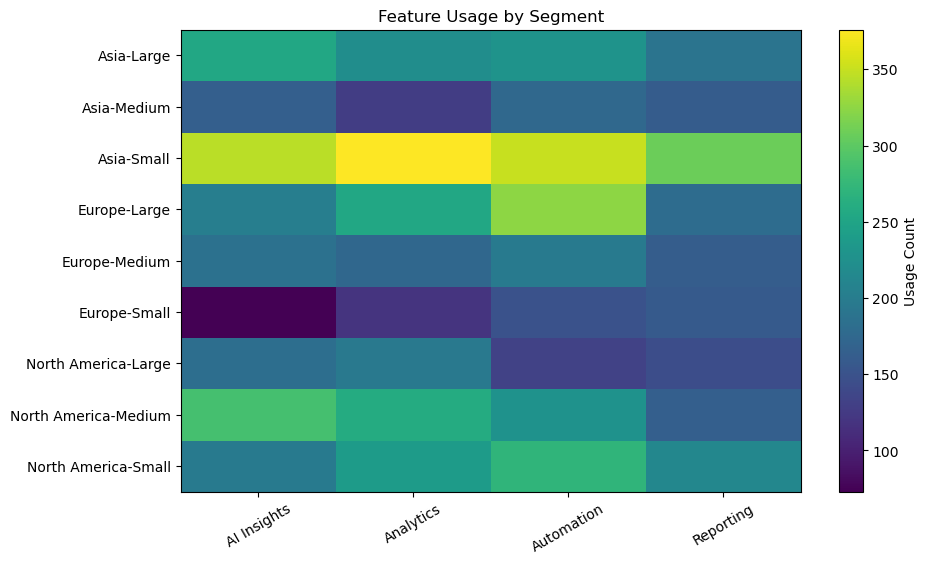

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(pivot_feature_segment, aspect='auto')

plt.colorbar(label="Usage Count")

plt.xticks(range(len(pivot_feature_segment.columns)), pivot_feature_segment.columns, rotation=30)
plt.yticks(range(len(pivot_feature_segment.index)),
           [f"{i[0]}-{i[1]}" for i in pivot_feature_segment.index])

plt.title("Feature Usage by Segment")
plt.show()

### Insight

Certain segments demonstrate both high usage and high revenue, indicating strong product-market fit. These segments should be prioritized for retention and expansion. Meanwhile, segments with high usage but lower revenue may present monetization opportunities.

## Conclusion

This analysis shows that:

- Feature adoption is strong across all products
- Regional differences exist in feature usage patterns
- High-value customer segments can be identified through usage and revenue

These insights can support:
- Sales prioritization
- Product improvement
- GTM strategy optimization